# Whether a customer will buy a product based on weather and discount status:

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



,Weather,Discount,Buy
0,Sunny,Yes,Yes
1,Rainy,No,No
2,Sunny,No,Yes
3,Sunny,Yes,Yes
4,Rainy,Yes,No
5,Rainy,No,No
6,Sunny,No,Yes
7,Rainy,Yes,Yes
8,Sunny,Yes,Yes
9,Sunny,No,Yes


# 1. load dataset

In [ ]:

data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 
                'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Sunny', 'Rainy'],
    'Discount': ['Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 
                 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes'],
    'Buy': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 
            'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)
df

In [ ]:
# Split features (X) and label (y)
X = df[['Weather', 'Discount']]
y = df['Buy']


In [ ]:
# 2. Encode categorical text to integers
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)


In [8]:

# 3. Split the data (larger test size for a better evaluation)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)


In [ ]:
# 4. Train the Categorical Naive Bayes model
model = CategoricalNB()
model.fit(X_train, y_train)


In [ ]:
# 5. Make predictions
y_pred = model.predict(X_test)


In [5]:
# 6. Evaluate and print results
print(f"True Labels: {y_test.tolist()}")
print(f"Predictions: {y_pred.tolist()}")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")


True Labels: ['Yes', 'No', 'No', 'Yes', 'No']
Predictions: ['Yes', 'No', 'No', 'Yes', 'No']
Accuracy: 100.0%


Confusion Matrix Array:
[[3 0]
 [0 2]]


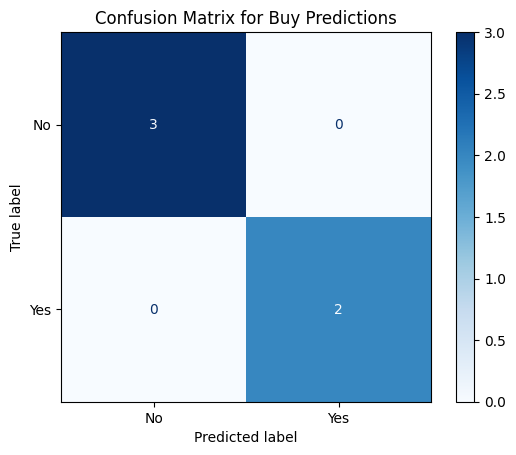

In [11]:
#  Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print("Confusion Matrix Array:")
print(cm)

#  Plot the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

# Show the plot window
plt.title("Confusion Matrix for Buy Predictions")
plt.show()